In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from nltk.corpus import stopwords
from nltk import *
from sklearn import *
import string
import json
import glob
import re
import csv
import bs4
import contractions
import os
from docx import Document
from pptx import Presentation
import requests
import PyPDF2
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from typing import List
import nltk
import import_ipynb
from Preprocessing import CleanText as cl 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


importing Jupyter notebook from Preprocessing.ipynb


In [2]:
def LoadTextData(filepath):
    ''' used this function due to all the cleaned text is written to a .txt file
        TFIFD vectorizer only need a list of strings not a text file
        using the file in read mode
    '''
    with open(filepath, 'r', encoding='utf-8') as file:
        data = file.readlines()  # Read lines into a list
    return data

# Load your data
data = LoadTextData(r"C:\\Projects\\Project SB\\TextModeling\\output\\CleanedText1.txt") # load your data as data variable

# Converts data into a list of strings
if not isinstance(data, list):
    data = [str(data)]  # Converts to list with a single string if data is a single string
else:
    data = [str(item).strip() for item in data]  # Ensure all items are strings

# TFIDFVectorizer identifies words based on the below conditions
vectorizer = TfidfVectorizer(
    lowercase=True,
    max_features=100,
    stop_words="english",
    min_df=0.01
)
'''
   How TF-IDF Works
   Term Frequency (TF): This simply measures how frequently a term occurs in a particular document.
   TF(t,d) = (Number of times term t appears in document d) / (Total number of terms in document d)
   
   Inverse Document Frequency (IDF): This measures how important a term is across the entire document set.   
   IDF(t) = log(N / df(t))
           N is the total number of documents in the corpus
           df(t) is the number of documents containing term t
           TF-IDF: This is the product of TF and IDF.

   TF-IDF(t,d) = TF(t,d) * IDF(t)
   '''
vectors = vectorizer.fit_transform(data)
# transforms the document into set of words into matrix forms based on 

tfidf_dense = vectors.todense()

# Fit and transform the text data
vectors = vectorizer.fit_transform(data)

# Convert the matrix to a dense format and display
tfidf_dense = vectors.todense()

# Show feature names and their corresponding TF-IDF scores
feature_names = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(tfidf_dense, columns=feature_names)

# Display the resulting DataFrame
print(tfidf_df)


        add  agricultur  agriculture        al  approach      bean   benefit  \
0  0.038619    0.226199     0.049653  0.033102  0.077239  0.044136  0.121375   

   bioenergi    calcul        ce  ...   sustain     track       use      wast  \
0   0.038619  0.071721  0.182062  ...  0.171028  0.038619  0.259301  0.319988   

      waste     water     wheat      work        wu      year  
0  0.110341  0.044136  0.049653  0.038619  0.044136  0.033102  

[1 rows x 100 columns]


In [3]:
n_samples = vectors.shape[0]
inertia = []
K = range(1, min(11, n_samples + 1))
for k in K:
    model = KMeans(n_clusters=k, init="k-means++", max_iter=100, n_init=10, random_state=42)
    model.fit(vectors)
    inertia.append(model.inertia_)
true_k = min(5, n_samples)
model = KMeans(n_clusters=true_k, init="k-means++", max_iter=100, n_init=10, random_state=42)
model.fit(vectors)
order_centroids = model.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()
with open("C:\\Projects\\Project SB\\TextModeling\\output\\outputcluster.txt", "w", encoding="utf-8") as f:
    for i in range(true_k):
        f.write(f"Cluster {i}\n")
        for ind in order_centroids[i, :10]:
            f.write(f' {terms[ind]}\n')
        f.write("\n\n")


In [4]:
KMeans_indices=model.fit_predict(vectors)

In [5]:
# ... existing code ...

n_components = 2  # Force 2 components for 2D visualization
pca = PCA(n_components=n_components)
scatter_plot_points = pca.fit_transform(vectors.toarray())

colors = ['r', 'b', 'c', 'y', 'm']
x_axis = scatter_plot_points[:, 0]
y_axis = scatter_plot_points[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(x_axis, y_axis, c=[colors[d % len(colors)] for d in KMeans_indices])

# Add labels and title
ax.set_xlabel('First Principal Component')
ax.set_ylabel('Second Principal Component')
ax.set_title('PCA of TF-IDF Vectors with K-Means Clustering')

# Add a legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {i}', 
                   markerfacecolor=c, markersize=10) for i, c in enumerate(colors[:len(set(KMeans_indices))])]
ax.legend(handles=legend_elements, title="Clusters")

# Annotate points (optional, may be cluttered with many points)
for i, txt in enumerate(data):
    ax.annotate(txt[:5], (x_axis[i], y_axis[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.savefig("C:\\Projects\\Project SB\\TextModeling\\outputcluster.png", dpi=300, bbox_inches='tight')
plt.show()

# ... existing code ...

ValueError: n_components=2 must be between 0 and min(n_samples, n_features)=1 with svd_solver='full'

In [7]:
# Print information about the data
print(f"Shape of vectors: {vectors.shape}")
print(f"Number of samples: {vectors.shape[0]}")
print(f"Number of features: {vectors.shape[1]}")
print(f"Number of clusters: {len(set(KMeans_indices))}")

# Check if we have enough samples and features for PCA
if vectors.shape[0] < 2 or vectors.shape[1] < 2:
    print("Not enough samples or features for PCA visualization.")
    print("Consider adding more data or using a different visualization method.")
else:
    # Proceed with PCA and visualization
    n_components = 2
    pca = PCA(n_components=n_components)
    scatter_plot_points = pca.fit_transform(vectors.toarray())

    colors = ['r', 'b', 'c', 'y', 'm']
    x_axis = scatter_plot_points[:, 0]
    y_axis = scatter_plot_points[:, 1]

    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(x_axis, y_axis, c=[colors[d % len(colors)] for d in KMeans_indices])

    # Add labels and title
    ax.set_xlabel('First Principal Component')
    ax.set_ylabel('Second Principal Component')
    ax.set_title('PCA of TF-IDF Vectors with K-Means Clustering')

    # Add a legend
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {i}', 
                       markerfacecolor=c, markersize=10) for i, c in enumerate(colors[:len(set(KMeans_indices))])]
    ax.legend(handles=legend_elements, title="Clusters")

    # Annotate points (optional, may be cluttered with many points)
    for i, txt in enumerate(data):
        ax.annotate(txt[:5], (x_axis[i], y_axis[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

    plt.tight_layout()
    plt.savefig("C:\\Projects\\Project SB\\TextModeling\\outputcluster.png", dpi=300, bbox_inches='tight')
    plt.show()

# Print additional information about PCA
if 'pca' in locals():
    print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
    print(f"Cumulative explained variance ratio: {np.cumsum(pca.explained_variance_ratio_)}")

Shape of vectors: (1, 100)
Number of samples: 1
Number of features: 100
Number of clusters: 1
Not enough samples or features for PCA visualization.
Consider adding more data or using a different visualization method.


AttributeError: 'PCA' object has no attribute 'explained_variance_ratio_'

Shape of vectors: (1, 100)
Number of samples: 1
Number of features: 100
Number of clusters: 1


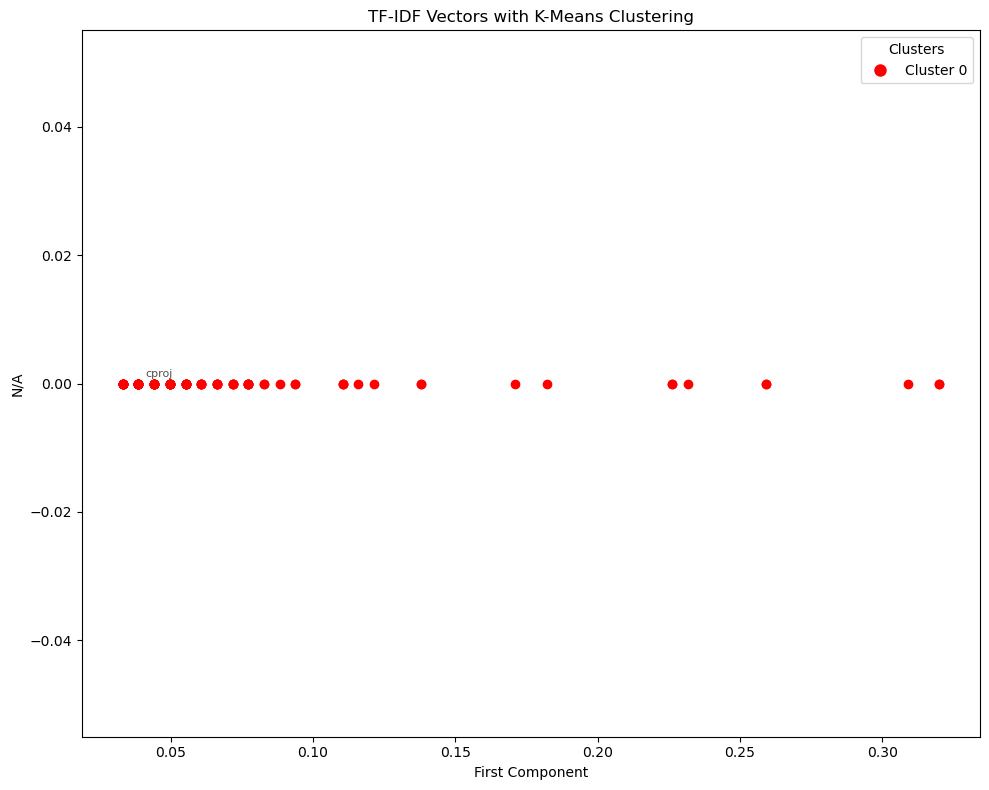

PCA was not performed due to insufficient dimensions.


In [8]:
# ... existing code ...

# Print information about the data
print(f"Shape of vectors: {vectors.shape}")
print(f"Number of samples: {vectors.shape[0]}")
print(f"Number of features: {vectors.shape[1]}")
print(f"Number of clusters: {len(set(KMeans_indices))}")

# Determine the number of components for PCA
n_components = min(2, vectors.shape[0], vectors.shape[1])

if n_components == 1:
    # If we only have one component, we'll create a 1D plot
    x_axis = vectors.toarray().flatten()
    y_axis = np.zeros_like(x_axis)
    pca_performed = False
else:
    # If we have at least 2 components, proceed with PCA
    pca = PCA(n_components=n_components)
    scatter_plot_points = pca.fit_transform(vectors.toarray())
    x_axis = scatter_plot_points[:, 0]
    y_axis = scatter_plot_points[:, 1] if n_components > 1 else np.zeros_like(x_axis)
    pca_performed = True

colors = ['r', 'b', 'c', 'y', 'm']

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(x_axis, y_axis, c=[colors[d % len(colors)] for d in KMeans_indices])

# Add labels and title
ax.set_xlabel('First Component')
ax.set_ylabel('Second Component' if n_components > 1 else 'N/A')
ax.set_title('TF-IDF Vectors with K-Means Clustering')

# Add a legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {i}', 
                   markerfacecolor=c, markersize=10) for i, c in enumerate(colors[:len(set(KMeans_indices))])]
ax.legend(handles=legend_elements, title="Clusters")

# Annotate points (optional, may be cluttered with many points)
for i, txt in enumerate(data):
    ax.annotate(txt[:5], (x_axis[i], y_axis[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.savefig("C:\\Projects\\Project SB\\TextModeling\\outputcluster.png", dpi=300, bbox_inches='tight')
plt.show()

# Print additional information about PCA
if pca_performed:
    print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
    print(f"Cumulative explained variance ratio: {np.cumsum(pca.explained_variance_ratio_)}")
else:
    print("PCA was not performed due to insufficient dimensions.")

# ... existing code ...

Shape of vectors: (1, 100)
Number of samples: 1
Number of features: 100
Number of clusters: 1


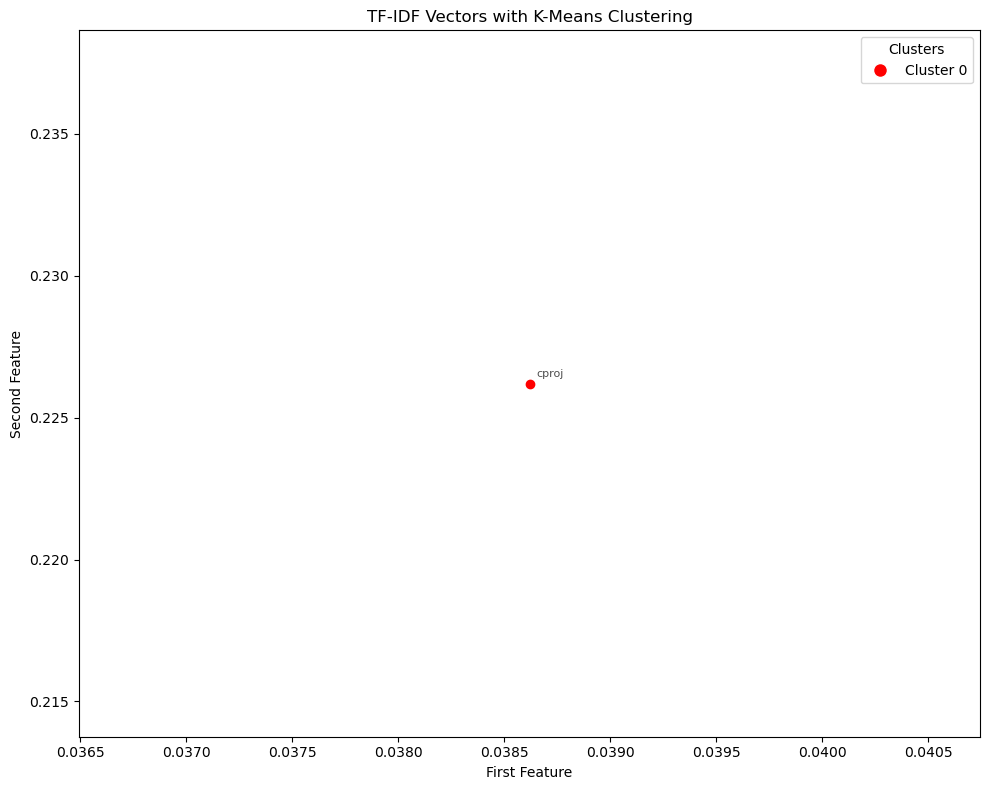

Number of dimensions used for plotting: 2
Plotting first two features of the TF-IDF vectors.


In [9]:
# ... existing code ...

# Print information about the data
print(f"Shape of vectors: {vectors.shape}")
print(f"Number of samples: {vectors.shape[0]}")
print(f"Number of features: {vectors.shape[1]}")
print(f"Number of clusters: {len(set(KMeans_indices))}")

# Convert sparse matrix to dense array
dense_vectors = vectors.toarray()

# Determine the number of dimensions for plotting
n_dims = min(2, dense_vectors.shape[1])

if n_dims == 1:
    # If we only have one feature, create a 1D plot
    x_axis = dense_vectors.flatten()
    y_axis = np.zeros_like(x_axis)
else:
    # If we have at least 2 features, use the first two for plotting
    x_axis = dense_vectors[:, 0]
    y_axis = dense_vectors[:, 1]

colors = ['r', 'b', 'c', 'y', 'm']

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(x_axis, y_axis, c=[colors[d % len(colors)] for d in KMeans_indices])

# Add labels and title
ax.set_xlabel('First Feature')
ax.set_ylabel('Second Feature' if n_dims > 1 else 'N/A')
ax.set_title('TF-IDF Vectors with K-Means Clustering')

# Add a legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {i}', 
                   markerfacecolor=c, markersize=10) for i, c in enumerate(colors[:len(set(KMeans_indices))])]
ax.legend(handles=legend_elements, title="Clusters")

# Annotate points (optional, may be cluttered with many points)
for i, txt in enumerate(data):
    ax.annotate(txt[:5], (x_axis[i], y_axis[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

plt.tight_layout()
plt.savefig("C:\\Projects\\Project SB\\TextModeling\\outputcluster.png", dpi=300, bbox_inches='tight')
plt.show()

# Print additional information
print(f"Number of dimensions used for plotting: {n_dims}")
if n_dims == 1:
    print("Only one dimension available. Plotting as a 1D scatter plot.")
else:
    print("Plotting first two features of the TF-IDF vectors.")

# ... existing code ...